In [1]:
import pandas as pd
import psycopg2
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = psycopg2.connect(
    host="localhost",
    database="instacart_db",
    user="postgres",
    password="112347"
)

In [ ]:
orders = pd.read_sql("SELECT * FROM orders", conn)
products = pd.read_sql("SELECT * FROM products", conn)
order_products = pd.read_sql("SELECT * FROM order_products_prior", conn)
departments= pd.read_sql("SELECT * FROM departments", conn)
aisles = pd.read_sql("SELECT * FROM aisles", conn)


C:\Users\saran\AppData\Local\Temp\ipykernel_19180\3636058907.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", conn)
C:\Users\saran\AppData\Local\Temp\ipykernel_19180\3636058907.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql("SELECT * FROM products", conn)
C:\Users\saran\AppData\Local\Temp\ipykernel_19180\3636058907.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_products = pd.read_sql("SELECT * FROM order_products_prior", conn)


In [ ]:
orders.head()

In [ ]:
orders.shape
products.shape
order_products.shape

In [24]:
orders.isnull().sum()
products.isnull().sum()
order_products.isnull().sum()


order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [25]:
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)

In [26]:
orders.duplicated().sum()
products.duplicated().sum()
order_products.duplicated().sum()

np.int64(0)

In [27]:
orders = orders.drop_duplicates()
products = products.drop_duplicates()
order_products = order_products.drop_duplicates()

In [28]:
orders.dtypes

order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

In [29]:
orders['order_dow'] = orders['order_dow'].astype(int)
orders['order_hour_of_day'] = orders['order_hour_of_day'].astype(int)

In [30]:
orders['order_hour_of_day'].unique()

array([18,  7, 16, 15, 14, 17, 12, 19,  9, 10,  8,  6, 13, 11,  5, 20, 22,
       21,  0, 23,  1,  4,  3,  2])

In [31]:
orders['order_dow'].unique()

array([5, 0, 4, 2, 3, 6, 1])

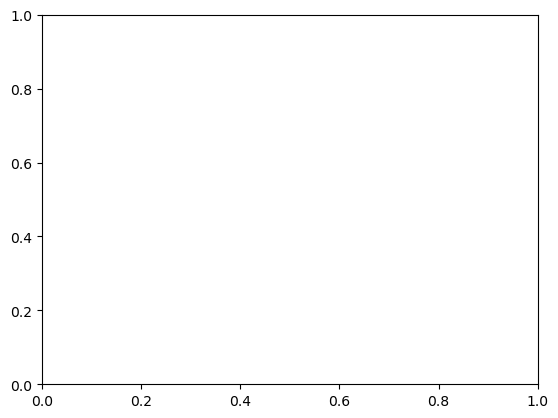

In [32]:
basket_size = order_products.groupby('order_id')['product_id'].count()

sns.boxplot(basket_size)
plt.show()

In [ ]:
data = order_products.merge(products, on='product_id')
data = data.merge(departments , on='department_id')
data = data.merge(aisles, on='aisle_id')
data = data.merge(orders, on='order_id')

In [ ]:
data.head()

In [ ]:
data.info()
data.describe()

In [ ]:
data.to_csv("clean_instacart_data.csv", index=False)

In [ ]:
import os
print(os.getcwd())